<a href="https://colab.research.google.com/github/zoroubo/MDS-lab/blob/main/Week_9%2C10%2C11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df=pd.read_csv('train.csv')

In [ ]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
missing=df.isnull().any(axis=1)
print(missing)

0       True
1      False
2       True
3      False
4       True
       ...  
886     True
887    False
888     True
889    False
890     True
Length: 891, dtype: bool


In [ ]:
print(df['Age'].isnull())

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: Age, Length: 891, dtype: bool


<Axes: >

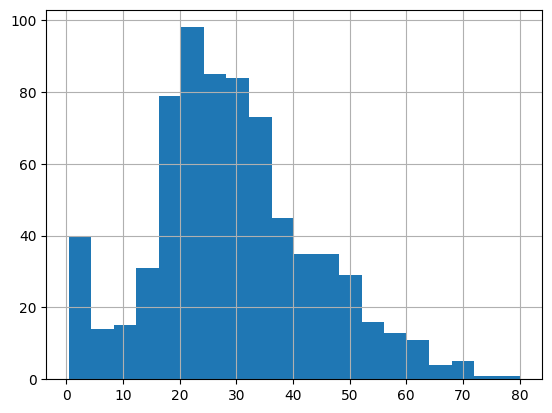

In [ ]:
df['Age'].hist(bins=20)

### (c) Detect and filter outliers.

In [ ]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers=df[(df["Age"]<lower) | (df["Age"]>upper)]
print(outliers)

     PassengerId  Survived  Pclass                                  Name  \
96            97         0       1             Goldschmidt, Mr. George B   
116          117         0       3                  Connors, Mr. Patrick   
493          494         0       1               Artagaveytia, Mr. Ramon   
630          631         1       1  Barkworth, Mr. Algernon Henry Wilson   
672          673         0       2           Mitchell, Mr. Henry Michael   
745          746         0       1          Crosby, Capt. Edward Gifford   
851          852         0       3                   Svensson, Mr. Johan   

      Sex   Age  SibSp  Parch      Ticket     Fare Cabin Embarked  
96   male  71.0      0      0    PC 17754  34.6542    A5        C  
116  male  70.5      0      0      370369   7.7500   NaN        Q  
493  male  71.0      0      0    PC 17609  49.5042   NaN        C  
630  male  80.0      0      0       27042  30.0000   A23        S  
672  male  70.0      0      0  C.A. 24580  10.5000 

In [ ]:
filtered=df[(df["Age"]>lower) & (df["Age"]<upper)]
print(filtered)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
885          886         0       3   
886          887         0       2   
887          888         1       1   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [ ]:
df["Age"].fillna(df["Age"].median())

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
885,39.0
886,27.0
887,19.0
889,26.0


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df=df.copy()
df.dropna(subset=["Embarked"],inplace=True)
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
x=df["Cabin"].isnull().mean() * 100
print(x)
df["Cabin"].notnull().sum()

73.29192546583852


np.int64(172)

In [ ]:
df["Cabin"].dropna().head(20)

,Cabin
1,C85
3,C123
6,E46
11,C103
21,D56
23,A6
27,C23 C25 C27
52,D33
54,B30
62,C83


In [ ]:
df["Deck"] = df["Cabin"].str[0]
df[["Cabin", "Deck"]].dropna().head(20)

,Cabin,Deck
1,C85,C
3,C123,C
6,E46,E
11,C103,C
21,D56,D
23,A6,A
27,C23 C25 C27,C
52,D33,D
54,B30,B
62,C83,C


In [ ]:
df["Deck"].value_counts(dropna=False)

,count
Deck,
NaN,472
C,49
B,42
D,31
E,29
A,11
F,7
G,2
T,1


In [ ]:
print(df.shape)
print(df["Cabin"].isnull().sum())

(644, 13)
472


In [ ]:
print(df["PassengerId"].nunique())

644


In [ ]:
df = pd.read_csv("train.csv")
print(df.shape)

(891, 12)


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers=df[(df["Age"]<lower) | (df["Age"]>upper)]
print(outliers)
print(len(outliers))

     PassengerId  Survived  Pclass                                  Name  \
33            34         0       2                 Wheadon, Mr. Edward H   
54            55         0       1        Ostby, Mr. Engelhart Cornelius   
96            97         0       1             Goldschmidt, Mr. George B   
116          117         0       3                  Connors, Mr. Patrick   
280          281         0       3                      Duane, Mr. Frank   
456          457         0       1             Millet, Mr. Francis Davis   
493          494         0       1               Artagaveytia, Mr. Ramon   
630          631         1       1  Barkworth, Mr. Algernon Henry Wilson   
672          673         0       2           Mitchell, Mr. Henry Michael   
745          746         0       1          Crosby, Capt. Edward Gifford   
851          852         0       3                   Svensson, Mr. Johan   

      Sex   Age  SibSp  Parch      Ticket     Fare Cabin Embarked  
33   male  66.0    

In [6]:
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Title counts after grouping rare titles:")
print(df['Title'].value_counts())

Title counts after grouping rare titles:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


## D-2)Implement Regularized Linear Regression

First, we need to prepare the data by handling categorical variables and selecting relevant features.

In [7]:
# Drop the original 'Name', 'Ticket', and 'Cabin' columns as they have been processed or are not relevant for direct modeling
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# Convert 'Sex', 'Embarked', and 'Title' to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

# Display the first few rows of the preprocessed DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,22.0,1,0,7.2500,True,False,True,False,True,False,False
1,2,1,1,38.0,1,0,71.2833,False,False,False,False,False,True,False
2,3,1,3,26.0,0,0,7.9250,False,False,True,True,False,False,False
3,4,1,1,35.0,1,0,53.1000,False,False,True,False,False,True,False
4,5,0,3,35.0,0,0,8.0500,True,False,True,False,True,False,False


In [8]:
# Impute missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Verify no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())

# Define features (X) and target (y)
X = df.drop('Survived', axis=1) # Assuming 'Survived' is the target for a regression-like problem
y = df['Survived']

print("\nFeatures (X) head:")
display(X.head())

Missing values after imputation:
PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
Title_Miss     0
Title_Mr       0
Title_Mrs      0
Title_Rare     0
dtype: int64

Features (X) head:


/tmp/ipykernel_810/1711696629.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,3,22.0,1,0,7.2500,True,False,True,False,True,False,False
1,2,1,38.0,1,0,71.2833,False,False,False,False,False,True,False
2,3,3,26.0,0,0,7.9250,False,False,True,True,False,False,False
3,4,1,35.0,1,0,53.1000,False,False,True,False,False,True,False
4,5,3,35.0,0,0,8.0500,True,False,True,False,True,False,False


### Train-Test Split and Feature Scaling

Before training the model, we split the data into training and testing sets and scale the numerical features. Scaling is particularly important for regularized models to ensure all features contribute equally to the distance calculations.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (exclude one-hot encoded and PassengerId)
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Scale numerical features
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train head after scaling:")
display(X_train.head())
print("\nX_test head after scaling:")
display(X_test.head())

X_train head after scaling:


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
331,332,-1.614136,1.253641,-0.470722,-0.479342,-0.078684,True,False,True,False,True,False,False
733,734,-0.400551,-0.477284,-0.470722,-0.479342,-0.377145,True,False,True,False,True,False,False
382,383,0.813034,0.215086,-0.470722,-0.479342,-0.474867,True,False,True,False,True,False,False
704,705,0.813034,-0.246494,0.379923,-0.479342,-0.476230,True,False,True,False,True,False,False
813,814,0.813034,-1.785093,2.931860,2.048742,-0.025249,False,False,True,True,False,False,False



X_test head after scaling:


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
709,710,0.813034,-0.092634,0.379923,0.784700,-0.333901,True,False,False,False,False,False,False
439,440,-0.400551,0.138156,-0.470722,-0.479342,-0.425284,True,False,True,False,True,False,False
840,841,0.813034,-0.708074,-0.470722,-0.479342,-0.474867,True,False,True,False,True,False,False
720,721,-0.400551,-1.785093,-0.470722,0.784700,0.007966,False,False,True,True,False,False,False
39,40,0.813034,-1.169653,0.379923,-0.479342,-0.411002,False,False,False,True,False,False,False


### Implement Regularized Linear Regression (Lasso)


In [10]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Lasso Regression model
# We'll start with a default alpha, which can be tuned later
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression Mean Squared Error: {mse_lasso:.4f}")
print(f"Lasso Regression R-squared: {r2_lasso:.4f}")

# Display coefficients (optional)
# coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_model.coef_})
# print("\nLasso Coefficients:")
# display(coef_df.sort_values(by='Coefficient', ascending=False))

Lasso Regression Mean Squared Error: 0.2002
Lasso Regression R-squared: 0.1743


## E)Develop a Model on Logistic Regression for Prediction


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
# Set max_iter for convergence, especially with scaled data
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_logistic)
conf_matrix = confusion_matrix(y_test, y_pred_logistic)
class_report = classification_report(y_test, y_pred_logistic)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Logistic Regression Accuracy: 0.7933

Confusion Matrix:
 [[87 18]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

